# EDA 9 (refined) — Time-symmetric mechanism tree (2011 vs 2021) -  added threshold justification

**Purpose.** 
EDA 7 & 8 exposed a definitional asymmetry: 
- *genuine cascade* was born from the 2011 comparison, 
- *exodus* from the 2021 anomaly, 
so the **categories were not applied symmetrically across census years**. The 2011 map could not honestly use "exodus" for its outflow-driven belt.

**Fix.** 
- Define a per-year **mechanism tree** that knows nothing about which year it is in.
- Every leaf is a measurable flow property; 
  - the narrative labels (*genuine cascade*, *exodus*) are **cross-year interpretations layered on top**, not categories in the tree.

```
Cascade-led in Frame C (national + external), year t
│
├─ Casc_Inflow_Share_t ≥ 0.25  ──────────────  INFLOW-LED
│    ├─ Typ_A_t == Cascade-led (frame-robust) →  (1) inflow-driven cascade
│    └─ not frame-robust                      →  (2) frame-sensitive inflow  [residual]
│
└─ Casc_Inflow_Share_t < 0.25  ──────────────  OUTFLOW-DOMINATED
     ├─ Ext arm share ≥ 0.5                   →  (3) outflow: external-majority
     └─ Ext arm share < 0.5                   →  (4) outflow: internal-majority
```

- **Ext arm share** = share of the Frame-C `Outflow_Poorer` arm that goes to the external node
  - (`Ext_Outflow_nat / Outflow_Poorer_nat`). 
  - Defined only for MSOAs **above national D6** (the external node is fixed at D6, so it only counts as "poorer" from above); 
  - set to 0 otherwise.
- **Narrative overlays:**
  - *Genuine cascade* = leaf (1) in **both** years (persistence condition).
  - *Exodus* = the interpretation of leaf (3) **as it appears in 2021**, licensed by the
    −17.8 % / +51.3 % external-flow shift. The 2011 leaf-(3) MSOAs are the baseline, not "a 2011 exodus".
  - Leaf (4) is mostly the **Frame B ladder artefact** (from national D8, most of London *is* poorer).
  - Leaf (2) is a visible residual: reported, not narrated.

**Inputs:** `eda4_results_for_phase3_20260626.csv`, `msoa_cascade_national_frame_20260625.csv`
(no upstream rerun of EDA 4/5 needed — the tree only consumes existing columns).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import sys

from pyprojroot import here

ROOT       = here()
sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / 'outputs'
EDA4 = DATA_DIR / 'eda4_results_for_phase3_20260626.csv'
NATF = DATA_DIR / 'msoa_cascade_national_frame_20260625.csv'

e4 = pd.read_csv(EDA4)
nf = pd.read_csv(NATF)

df = e4.merge(
    nf[['msoa11cd',
        'Outflow_Poorer_nat_11', 'Ext_Outflow_nat_11',
        'Outflow_Poorer_nat_21', 'Ext_Outflow_nat_21',
        'Ext_Inflow_nat_11', 'Ext_Inflow_nat_21']],
    on='msoa11cd', validate='1:1')
print(df.shape)

(982, 48)


---
## 1. External share of the Outflow-Poorer arm

The external node sits at national D6, so external outflow contributes to `Outflow_Poorer_nat`
**only for MSOAs above D6**. For MSOAs at/below D6 the arm contains no external component by
construction, so the share is fixed at 0. (Diagnostic below shows this exclusion is immaterial:
0 of 168 outflow-dominated MSOAs in 2021 sit at/below D6.)

In [2]:
for yr in ('11', '21'):
    arm = df[f'Outflow_Poorer_nat_{yr}'].replace(0, np.nan)
    share = df[f'Ext_Outflow_nat_{yr}'] / arm
    df[f'Ext_Arm_Share_{yr}'] = np.where(df['Wealth_Decile_National'] > 6, share, 0.0)
    df[f'Ext_Arm_Share_{yr}'] = df[f'Ext_Arm_Share_{yr}'].fillna(0.0)

# sanity: external outflow is a subset of the poorer arm above D6
hi = df[df['Wealth_Decile_National'] > 6]
assert (hi['Ext_Outflow_nat_21'] <= hi['Outflow_Poorer_nat_21']).all()
assert (hi['Ext_Outflow_nat_11'] <= hi['Outflow_Poorer_nat_11']).all()
print('sanity OK: Ext_Outflow ⊆ Outflow_Poorer arm for national decile > 6')

sanity OK: Ext_Outflow ⊆ Outflow_Poorer arm for national decile > 6


---
## 2. The tree

Two thresholds:
- `INFLOW_MIN = 0.25` — sits in an **empirical gap** of the inflow-share distribution among
  frame-robust cascades in both years (verified in §5).
- `EXT_MAJ = 0.5` — a *majority convention*, **not** empirically gapped (verified in §5),
  so a ±0.05 sensitivity band is reported alongside.

### Locating `INFLOW_MIN` — the empirical gap

**Why need to split?**
The inflow share (`IW / (IW + OP)`) asks whether the affluent-inflow arm is a substantive component of an area's cascade churn 
- **not** whether inflow outweighs outflow. 

**Why not 0.5?**
Under the chain-displacement mechanism (Marcuse 1985) the outflow arm is *expected* to be comparable to or larger than the inflow arm (one arrival can trigger several downward moves, and the outflow arm carries the displaced), so a 0.5 cut would misclassify the archetypal genuine
cascades (Camden 026: 0.46/0.40; Tower Hamlets 010: 0.49/0.45) as outflow-driven.

**How to find where to cut?**
Instead the threshold is located by the data. 

Among frame-robust cascade-led MSOAs the distribution of inflow shares is bimodal: 
- a cluster hugging zero (near-pure outflow) and 
- a continuum starting around 0.3, 
separated by an interval that is **empty in both censuses independently**. 

***Any threshold inside the shared empty interval yields an identical classification in both years,*** so the exact value of 0.25 carries no weight 
— it is a round number inside a gap the data drew. 
- The Yee overlap in EDA 5 corroborates the split's substantive meaning *after the fact*
    - it plays no role in locating it, 
    - keeping the classifier non-circular.

Caveat, stated for the record: 
n is modest (69 / 26), and gaps can arise by chance in small samples. 
The ***defence*** is that 
1. the **same interval is empty in two independent censuses**, 
2. the classification is invariant across the whole interval, and 
3. the two groups differ by roughly an order of magnitude (0.01–0.23 vs 0.30–1.00).

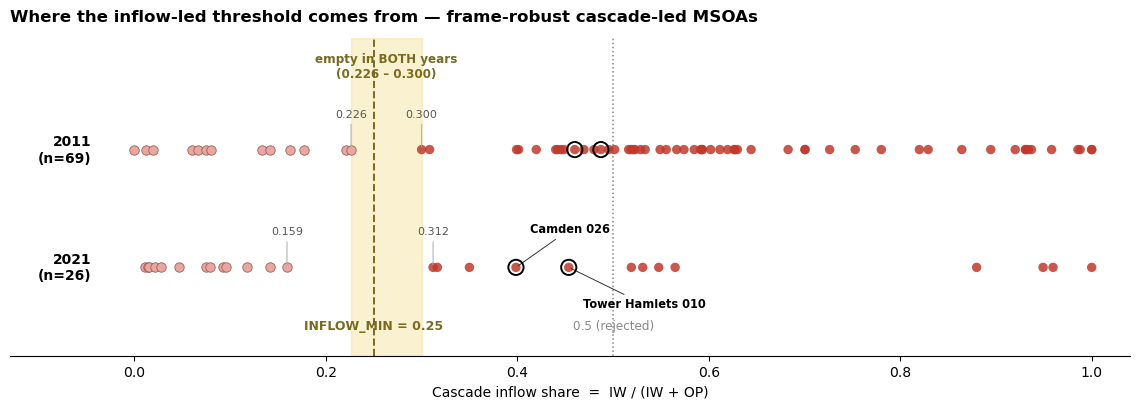

2011 gap: 0.226 → 0.300
2021 gap: 0.159 → 0.312
shared empty interval: (0.226, 0.300) — any cut inside it classifies identically in both years


In [4]:
# ── evidence figure: the empirical gap that locates INFLOW_MIN ───────────
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

PROVISIONAL_MIN = 0.25          # candidate cut; validated against the gap below
CL, CH = '#e8a7a0', '#c0392b'   # low cluster (near-pure outflow) / inflow-led continuum

fig, ax = plt.subplots(figsize=(11.5, 4.2))
rows, edges = {'11': 1.0, '21': 0.0}, {}

for yr, y in rows.items():
    fr = df[(df[f'Typ_C_{yr}'] == 'Cascade-led') & (df[f'Typ_A_{yr}'] == 'Cascade-led')]
    s = np.sort(fr[f'Casc_Inflow_Share_{yr}'].values)
    lo, hi = s[s < PROVISIONAL_MIN], s[s >= PROVISIONAL_MIN]
    edges[yr] = (lo.max(), hi.min())
    ax.scatter(lo, np.full(len(lo), y), s=46, c=CL, edgecolors='#9c5f58', lw=0.6, zorder=3)
    ax.scatter(hi, np.full(len(hi), y), s=46, c=CH, edgecolors='none', alpha=0.85, zorder=3)
    ax.text(-0.045, y, f'20{yr}\n(n={len(s)})', ha='right', va='center',
            fontsize=10, fontweight='bold')
    for gx in edges[yr]:
        ax.annotate(f'{gx:.3f}', xy=(gx, y), xytext=(gx, y + 0.28), fontsize=8,
                    ha='center', color='#555',
                    arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.7))

# shared empty interval = intersection of the two per-year gaps
band_lo = max(e[0] for e in edges.values())
band_hi = min(e[1] for e in edges.values())
assert band_lo < PROVISIONAL_MIN < band_hi, 'threshold must sit inside the shared gap'
ax.axvspan(band_lo, band_hi, color='#f5e6a8', alpha=0.55, zorder=1)
ax.text((band_lo + band_hi) / 2, 1.62,
        f'empty in BOTH years\n({band_lo:.3f} \u2013 {band_hi:.3f})',
        ha='center', fontsize=8.6, color='#7a6a1f', fontweight='bold')
ax.axvline(PROVISIONAL_MIN, color='#7a6a1f', lw=1.4, ls='--', zorder=2)
ax.text(PROVISIONAL_MIN, -0.52, f'INFLOW_MIN = {PROVISIONAL_MIN}', ha='center',
        fontsize=9, color='#7a6a1f', fontweight='bold')

# the rejected 0.5 counterfactual, with the archetypes it would expel
ax.axvline(0.50, color='#888', lw=1.1, ls=':', zorder=2)
ax.text(0.50, -0.52, '0.5 (rejected)', ha='center', fontsize=8.6, color='#888')
for c, n, dy in [('E02000191', 'Camden 026', 0.30),
                 ('E02000873', 'Tower Hamlets 010', -0.34)]:
    for yr, y in rows.items():
        v = df.loc[df['msoa11cd'] == c, f'Casc_Inflow_Share_{yr}'].iloc[0]
        ax.scatter([v], [y], s=120, facecolors='none', edgecolors='black', lw=1.4, zorder=4)
        if yr == '21':
            ax.annotate(n, xy=(v, y), xytext=(v + 0.015, y + dy), fontsize=8.2,
                        fontweight='bold',
                        arrowprops=dict(arrowstyle='-', color='#333', lw=0.7))

ax.set_xlim(-0.13, 1.04); ax.set_ylim(-0.75, 1.95); ax.set_yticks([])
ax.set_xlabel('Cascade inflow share  =  IW / (IW + OP)', fontsize=10)
for sp in ('left', 'right', 'top'):
    ax.spines[sp].set_visible(False)
ax.set_title('Where the inflow-led threshold comes from \u2014 frame-robust cascade-led MSOAs',
             fontsize=12, fontweight='bold', loc='left', pad=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'case_study' / 'fig01_inflow_share_gap_20260705.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f'2011 gap: {edges["11"][0]:.3f} \u2192 {edges["11"][1]:.3f}')
print(f'2021 gap: {edges["21"][0]:.3f} \u2192 {edges["21"][1]:.3f}')
print(f'shared empty interval: ({band_lo:.3f}, {band_hi:.3f}) \u2014 any cut inside it '
      f'classifies identically in both years')

### Locating `EXT_MAJ` — a stated convention, defended by sensitivity

The external arm share (`Ext_Outflow / Outflow_Poorer`, for MSOAs above national D6) has **no empirical gap**: 
- among outflow-dominated cascade-led MSOAs the distribution is dense straight through 0.40–0.60 in both years, 
- so no cut in that region is data-located the way `INFLOW_MIN` is. 
- Pretending otherwise would be the arbitrariness worth worrying about;

instead the threshold is declared for what it is — a **majority convention** — and defended on two grounds:

1. **Semantics.** 
- 0.5 is the unique value at which the class label is literally true:
   - "the majority of this area's poorer-directed outflow leaves London." 
   - Any other cut would need a justification 0.5 does not.
2. **Sensitivity.** 
- The finding the threshold feeds — the emergence of the externally-drained class — survives every reasonable cut. 
- At 0.45 / 0.50 / 0.55 the counts are 38→103, 19→78, 8→46: 
   - the growth ratio (×2.7 / ×4.1 / ×5.8) *strengthens* as the cut tightens, and 
   - the 100%-outer-London geography holds throughout. 
- The class boundary moves; the phenomenon does not.

One structural note: MSOAs at or below national D6 have share 0 by construction
- the external node at D6 is not "poorer" from there, 
- but this exclusion is immaterial 
   - essentially none of the outflow-dominated MSOAs sit at or below D6 (verified in §4e).

Together with the previous subsection this gives the tree one threshold of each kind, each labelled honestly: 
- `INFLOW_MIN` located by an empirical gap; 
- `EXT_MAJ` a stated majority convention with its sensitivity band on the record.

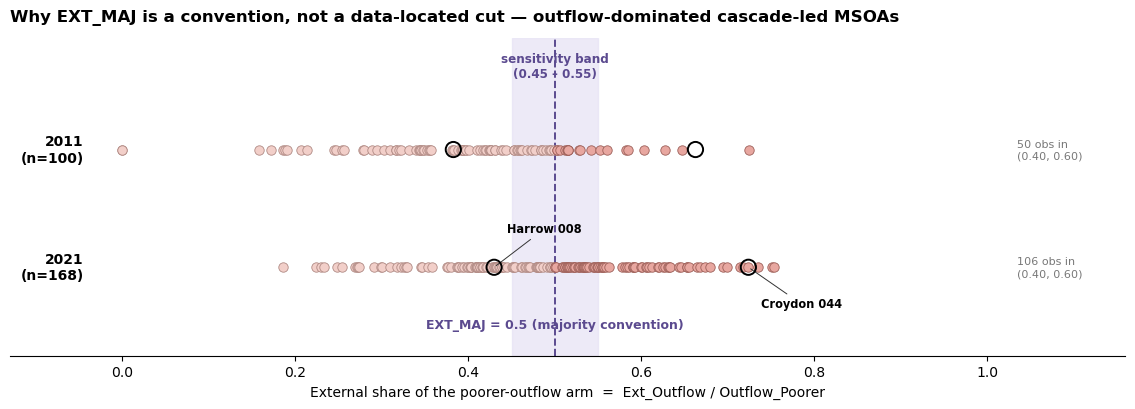

External-majority counts and growth across the sensitivity band
   cut   2011   2021   ratio
  0.45     38    103    ×2.7
  0.50     19     78    ×4.1
  0.55      8     46    ×5.8

The class boundary moves with the cut; the emergence finding does not.


In [6]:
# ── evidence figure: EXT_MAJ has no gap → convention + sensitivity band ──
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'

EXT_CONVENTION = 0.5
CUTS = (0.45, 0.50, 0.55)
CL2, CH2 = '#f2cfc9', '#e8a7a0'   # internal-majority side / external-majority side

fig, ax = plt.subplots(figsize=(11.5, 4.2))
rows = {'11': 1.0, '21': 0.0}
sens = {}

for yr, y in rows.items():
    od = df[(df[f'Typ_C_{yr}'] == 'Cascade-led') &
            (df[f'Casc_Inflow_Share_{yr}'] < 0.25)]
    s = np.sort(od[f'Ext_Arm_Share_{yr}'].values)
    lo, hi = s[s < EXT_CONVENTION], s[s >= EXT_CONVENTION]
    ax.scatter(lo, np.full(len(lo), y), s=46, c=CL2, edgecolors='#b08a84', lw=0.6, zorder=3)
    ax.scatter(hi, np.full(len(hi), y), s=46, c=CH2, edgecolors='#9c5f58', lw=0.6, zorder=3)
    ax.text(-0.045, y, f'20{yr}\n(n={len(s)})', ha='right', va='center',
            fontsize=10, fontweight='bold')
    sens[yr] = {c: int((s >= c).sum()) for c in CUTS}
    # density check in the would-be gap region: how many observations in 0.40–0.60?
    dense = int(((s > 0.40) & (s < 0.60)).sum())
    ax.text(1.035, y, f'{dense} obs in\n(0.40, 0.60)', ha='left', va='center',
            fontsize=8, color='#777')

# sensitivity band + convention line
ax.axvspan(CUTS[0], CUTS[-1], color='#e6e2f5', alpha=0.7, zorder=1)
ax.text((CUTS[0] + CUTS[-1]) / 2, 1.62, 'sensitivity band\n(0.45 \u2013 0.55)',
        ha='center', fontsize=8.6, color='#5b4a8f', fontweight='bold')
ax.axvline(EXT_CONVENTION, color='#5b4a8f', lw=1.4, ls='--', zorder=2)
ax.text(EXT_CONVENTION, -0.52, f'EXT_MAJ = {EXT_CONVENTION} (majority convention)',
        ha='center', fontsize=9, color='#5b4a8f', fontweight='bold')

# exemplars: the C/D case-study contrast
for c, n, dy in [('E02000440', 'Harrow 008', 0.30),
                 ('E02000237', 'Croydon 044', -0.34)]:
    for yr, y in rows.items():
        sub = df.loc[df['msoa11cd'] == c]
        v = sub[f'Ext_Arm_Share_{yr}'].iloc[0]
        ax.scatter([v], [y], s=120, facecolors='none', edgecolors='black', lw=1.4, zorder=4)
        if yr == '21':
            ax.annotate(n, xy=(v, y), xytext=(v + 0.015, y + dy), fontsize=8.2,
                        fontweight='bold',
                        arrowprops=dict(arrowstyle='-', color='#333', lw=0.7))

ax.set_xlim(-0.13, 1.16); ax.set_ylim(-0.75, 1.95); ax.set_yticks([])
ax.set_xlabel('External share of the poorer-outflow arm  =  Ext_Outflow / Outflow_Poorer',
              fontsize=10)
for sp in ('left', 'right', 'top'):
    ax.spines[sp].set_visible(False)
ax.set_title('Why EXT_MAJ is a convention, not a data-located cut \u2014 '
             'outflow-dominated cascade-led MSOAs', fontsize=12, fontweight='bold',
             loc='left', pad=12)
plt.tight_layout()
plt.savefig(DATA_DIR / 'case_study' / 'fig02_ext_arm_convention_20260705.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

# printed sensitivity table for the Results chapter
print('External-majority counts and growth across the sensitivity band')
print(f'{"cut":>6} {"2011":>6} {"2021":>6} {"ratio":>7}')
# for c in CUTS:
#     n11, n21 = sens['11'][c], sens['21'][c]
#     print(f'{c:>6.2f} {n11:>6} {n21:>6} {"\u00d7" + f"{n21/n11:.1f}":>7}')
for c in CUTS:
    n11, n21 = sens['11'][c], sens['21'][c]
    ratio = f'×{n21 / n11:.1f}'
    print(f'{c:>6.2f} {n11:>6} {n21:>6} {ratio:>7}')
print('\nThe class boundary moves with the cut; the emergence finding does not.')

In [7]:
INFLOW_MIN = 0.25   # empirical gap: 0.226→0.300 (2011), 0.159→0.312 (2021)
EXT_MAJ    = 0.50   # majority convention — see sensitivity in §5

LEAVES = ['inflow-driven', 'frame-sensitive inflow',
          'outflow: external-majority', 'outflow: internal-majority']

def mechanism(row, yr):
    """Per-year mechanism leaf for Frame-C cascade-led MSOAs; None otherwise."""
    if row[f'Typ_C_{yr}'] != 'Cascade-led':
        return None
    inflow_led = row[f'Casc_Inflow_Share_{yr}'] >= INFLOW_MIN
    robust     = row[f'Typ_A_{yr}'] == 'Cascade-led'
    if inflow_led:
        return 'inflow-driven' if robust else 'frame-sensitive inflow'
    ext_major = row[f'Ext_Arm_Share_{yr}'] >= EXT_MAJ
    return 'outflow: external-majority' if ext_major else 'outflow: internal-majority'

for yr in ('11', '21'):
    df[f'leaf_{yr}'] = df.apply(mechanism, axis=1, yr=yr)

# narrative overlay: genuine = inflow-driven in BOTH years
df['Genuine_Persistent'] = (df['leaf_11'] == 'inflow-driven') & (df['leaf_21'] == 'inflow-driven')
print('classified.')

classified.


---
## 3. Leaf-count table (dissertation table)

The same tree, both years. The asymmetry is now an **empirical finding**, not a definitional flaw:
the inflow-driven leaf collapses, the external-majority leaf explodes.

In [8]:
tab = pd.DataFrame({
    '2011': df['leaf_11'].value_counts().reindex(LEAVES).fillna(0).astype(int),
    '2021': df['leaf_21'].value_counts().reindex(LEAVES).fillna(0).astype(int),
})
tab.loc['— cascade-led total'] = tab.sum()
tab['Δ'] = tab['2021'] - tab['2011']
print(tab.to_string())
print()
print(f"Genuine cascade (inflow-driven in BOTH years): {int(df['Genuine_Persistent'].sum())} MSOAs")

                            2011  2021   Δ
inflow-driven                 56    13 -43
frame-sensitive inflow        57    14 -43
outflow: external-majority    19    78  59
outflow: internal-majority    81    90   9
— cascade-led total          213   195 -18

Genuine cascade (inflow-driven in BOTH years): 8 MSOAs


---
## 4. Quick-analysis results, verified and printed for the Results chapter

Each block reproduces one claim from the working analysis; keep the printed output for citation.

In [11]:
# 4a. The external-flow shift that licenses the 'exodus' reading of 2021 leaf (3)
i11, i21 = nf['Ext_Inflow_nat_11'].sum(),  nf['Ext_Inflow_nat_21'].sum()
o11, o21 = nf['Ext_Outflow_nat_11'].sum(), nf['Ext_Outflow_nat_21'].sum()
print(f'Inflow from external: {i11:>7,} → {i21:>7,}  ({(i21/i11-1)*100:+.1f} %)')
print(f'Outflow to external: {o11:>7,} → {o21:>7,}  ({(o21/o11-1)*100:+.1f} %)')

Inflow from external: 187,595 → 154,172  (-17.8 %)
Outflow to external: 219,221 → 331,600  (+51.3 %)


In [12]:
# 4b. The emergence of the externally-drained class — sharpest single statistic
n11 = (df['leaf_11'] == 'outflow: external-majority').sum()
n21 = (df['leaf_21'] == 'outflow: external-majority').sum()
print(f'External-majority outflow cascades: {n11} (2011) → {n21} (2021)  = ×{n21/n11:.1f}')
for yr in ('11', '21'):
    sub = df[df[f'leaf_{yr}'] == 'outflow: external-majority']
    print(f"  20{yr} ring distribution: {sub['Ring'].value_counts().to_dict()}"
          f"  | boroughs: {sorted(sub['ladnm'].unique())}")

External-majority outflow cascades: 19 (2011) → 78 (2021)  = ×4.1
  2011 ring distribution: {'Outer': 19}  | boroughs: ['Barnet', 'Bexley', 'Croydon', 'Havering', 'Hillingdon', 'Kingston upon Thames', 'Richmond upon Thames', 'Sutton']
  2021 ring distribution: {'Outer': 78}  | boroughs: ['Barnet', 'Bexley', 'Bromley', 'Croydon', 'Enfield', 'Havering', 'Hillingdon', 'Kingston upon Thames', 'Merton', 'Redbridge', 'Richmond upon Thames', 'Sutton']


In [13]:
# 4c. Continuity with the earlier robustness-first ordering (quick-analysis numbers)
# (there, ext-majority was counted over ALL non-genuine cascade-led MSOAs)
for yr in ('11', '21'):
    casc = df[df[f'Typ_C_{yr}'] == 'Cascade-led']
    genuine = (casc[f'Typ_A_{yr}'] == 'Cascade-led') & (casc[f'Casc_Inflow_Share_{yr}'] >= INFLOW_MIN)
    extmaj  = (~genuine) & (casc[f'Ext_Arm_Share_{yr}'] >= EXT_MAJ)
    resid   = (~genuine) & (casc[f'Casc_Inflow_Share_{yr}'] >= INFLOW_MIN)
    print(f'20{yr}: genuine {genuine.sum():>3} | outflow-driven(rest) {(~genuine).sum():>3} '
          f'| ext-majority {extmaj.sum():>3} | residual (inflow-led, frame-sensitive) {resid.sum():>3}')
print()
print('Note: arm-first tree gives 19→78 (×4.1); robustness-first gives 25→89 (×3.6).')
print('Report the arm-first numbers in the tree table; cite either — direction identical.')

2011: genuine  56 | outflow-driven(rest) 157 | ext-majority  25 | residual (inflow-led, frame-sensitive)  57
2021: genuine  13 | outflow-driven(rest) 182 | ext-majority  89 | residual (inflow-led, frame-sensitive)  14

Note: arm-first tree gives 19→78 (×4.1); robustness-first gives 25→89 (×3.6).
Report the arm-first numbers in the tree table; cite either — direction identical.


In [14]:
# 4d. Threshold checks
# (i) INFLOW_MIN = 0.25 sits in an empirical gap among frame-robust cascades — both years
for yr in ('11', '21'):
    fr = df[(df[f'Typ_C_{yr}'] == 'Cascade-led') &
            (df[f'Typ_A_{yr}'] == 'Cascade-led')][f'Casc_Inflow_Share_{yr}'].sort_values()
    print(f'20{yr}: inflow-share gap around 0.25 → {fr[fr < .25].max():.3f} → {fr[fr >= .25].min():.3f}')

# (ii) EXT_MAJ = 0.5 has NO empirical gap → report sensitivity band instead
print()
for yr in ('11', '21'):
    od = df[df[f'leaf_{yr}'].isin(['outflow: external-majority', 'outflow: internal-majority'])]
    s = od[f'Ext_Arm_Share_{yr}']
    print(f'20{yr}: ext-majority count at threshold 0.45 / 0.50 / 0.55 = '
          f'{(s >= .45).sum()} / {(s >= .50).sum()} / {(s >= .55).sum()}   (n outflow-dominated = {len(od)})')
print()
print('→ 0.25 is empirically gapped; 0.5 is a stated majority convention with the ±0.05 band above.')

2011: inflow-share gap around 0.25 → 0.226 → 0.300
2021: inflow-share gap around 0.25 → 0.159 → 0.312

2011: ext-majority count at threshold 0.45 / 0.50 / 0.55 = 38 / 19 / 8   (n outflow-dominated = 100)
2021: ext-majority count at threshold 0.45 / 0.50 / 0.55 = 103 / 78 / 46   (n outflow-dominated = 168)

→ 0.25 is empirically gapped; 0.5 is a stated majority convention with the ±0.05 band above.


In [15]:
# 4e. Structural-exclusion diagnostic for the D6 rule (immaterial)
for yr in ('11', '21'):
    od = df[(df[f'Typ_C_{yr}'] == 'Cascade-led') & (df[f'Casc_Inflow_Share_{yr}'] < INFLOW_MIN)]
    print(f'20{yr}: outflow-dominated MSOAs at/below national D6 '
          f'(cannot be external-majority by construction): {(od.Wealth_Decile_National <= 6).sum()} of {len(od)}')

2011: outflow-dominated MSOAs at/below national D6 (cannot be external-majority by construction): 2 of 100
2021: outflow-dominated MSOAs at/below national D6 (cannot be external-majority by construction): 0 of 168


In [16]:
# 4f. Persistence — the genuine-cascade roster
gen = df[df['Genuine_Persistent']][['msoa11cd', 'ladnm', 'Ring',
                                    'Casc_Inflow_Share_11', 'Casc_Inflow_Share_21']]
print(gen.to_string(index=False))

 msoa11cd         ladnm  Ring  Casc_Inflow_Share_11  Casc_Inflow_Share_21
E02000189        Camden Inner              0.495485              0.547678
E02000191        Camden Inner              0.460000              0.398544
E02000508    Hillingdon Outer              0.566450              0.530973
E02000509    Hillingdon Outer              0.933834              0.949196
E02000575     Islington Inner              0.601981              0.564836
E02000808     Southwark Inner              0.522954              0.519065
E02000815     Southwark Inner              0.401283              0.311948
E02000873 Tower Hamlets Inner              0.487281              0.453700


In [17]:
# 4g. Case-study MSOAs (EDA 7/8) re-read through the tree
CASES = {'E02000191': 'Camden 026',        'E02000873': 'Tower Hamlets 010',
         'E02000809': 'Southwark 003',     'E02000561': 'Islington 008',
         'E02000957': 'Wandsworth 035',    'E02000440': 'Harrow 008',
         'E02000461': 'Harrow 029'}
cs = df[df['msoa11cd'].isin(CASES)].copy()
cs['case'] = cs['msoa11cd'].map(CASES)
print(cs[['case', 'leaf_11', 'leaf_21',
          'Casc_Inflow_Share_21', 'Ext_Arm_Share_21']].to_string(index=False))
print()
print('⚠ Harrow 008/029 are outflow-dominated but INTERNAL-majority (ext arm 0.43 / 0.41):')
print('  they exemplify the Frame-B ladder artefact (from D8 nearly all of London is poorer),')
print('  NOT the literal exodus. Use them as the internal-reshuffle worked example.')

             case                    leaf_11                    leaf_21  Casc_Inflow_Share_21  Ext_Arm_Share_21
       Camden 026              inflow-driven              inflow-driven              0.398544          0.000000
       Harrow 008 outflow: internal-majority outflow: internal-majority              0.011250          0.429836
       Harrow 029                        NaN outflow: internal-majority              0.038184          0.409871
    Islington 008              inflow-driven                        NaN              0.511602          0.000000
    Southwark 003     frame-sensitive inflow                        NaN              0.641321          0.000000
Tower Hamlets 010              inflow-driven              inflow-driven              0.453700          0.000000
   Wandsworth 035              inflow-driven                        NaN              0.801413          0.000000

⚠ Harrow 008/029 are outflow-dominated but INTERNAL-majority (ext arm 0.43 / 0.41):
  they exemplify th

In [18]:
# 4h. Recommended literal-exodus exemplars (highest ext-arm share, 2021)
od21 = df[df['leaf_21'] == 'outflow: external-majority']
print(od21.nlargest(8, 'Ext_Arm_Share_21')
          [['msoa11cd', 'ladnm', 'Wealth_Decile_National',
            'Casc_Inflow_Share_21', 'Ext_Arm_Share_21']].to_string(index=False))

 msoa11cd                ladnm  Wealth_Decile_National  Casc_Inflow_Share_21  Ext_Arm_Share_21
E02000232              Croydon                       7              0.151442          0.753541
E02000481             Havering                       8              0.141473          0.751693
E02000863               Sutton                       7              0.162162          0.734491
E02000237              Croydon                       8              0.031579          0.723913
E02000502           Hillingdon                       7              0.185515          0.717629
E02000235              Croydon                       7              0.132150          0.713636
E02000470             Havering                       7              0.169620          0.699695
E02000616 Kingston upon Thames                       9              0.040161          0.694561


---
## 5. Export

Single interface for the updated EDA 7/8 visuals: per-year leaves, ext-arm shares, persistence flag.

In [19]:
out_cols = ['msoa11cd', 'ladnm', 'Ring', 'Wealth_Decile_National',
            'Typ_A_11', 'Typ_C_11', 'Casc_Inflow_Share_11', 'Ext_Arm_Share_11', 'leaf_11',
            'Typ_A_21', 'Typ_C_21', 'Casc_Inflow_Share_21', 'Ext_Arm_Share_21', 'leaf_21',
            'Genuine_Persistent']
export_path = DATA_DIR / 'eda9_mechanism_tree_20260705.csv'
df[out_cols].to_csv(export_path, index=False)
print(f'exported: {export_path}  {df[out_cols].shape}')

exported: /Users/xing/Desktop/CASA/dissertation/outputs/eda9_mechanism_tree_20260705.csv  (982, 15)


---
## 6. Drop-in for EDA 8 — five-class temporal side-by-side maps

Replaces the per-year `classify()` and legend. The 2011 panel is now legitimate: it shows the
small external-majority baseline instead of mislabelling the whole outflow belt "exodus".
Legend wording keeps mechanism names on the map; put the narrative labels in the caption:

> *"Genuine cascade" = inflow-driven in both panels; "exodus" = the 2021 external-majority class,
> read against its 2011 baseline (19 → 78 MSOAs, all outer London).*

In [ ]:
# ── EDA 8 drop-in: classification + palette + legend ────────────────────
mech9 = pd.read_csv(DATA_DIR / 'eda9_mechanism_tree_20260704.csv')

PALETTE = {
    'inflow-driven':              '#c0392b',  # deep red   — gentrification signature
    'frame-sensitive inflow':     '#e67e22',  # amber      — residual, reported not narrated
    'outflow: external-majority': '#e8a7a0',  # pale red   — exodus signature (2021 reading)
    'outflow: internal-majority': '#f2cfc9',  # paler red  — Frame-B ladder artefact
    'counter':                    '#6a51a3',  # purple
    'other':                      '#e9e7e2',  # grey fabric
}

def map_class(row, yr):
    leaf = row[f'leaf_{yr}']
    if isinstance(leaf, str):
        return leaf
    return 'counter' if row[f'Typ_C_{yr}'] == 'Counter-led' else 'other'

for yr in ('11', '21'):
    mech9[f'map_class_{yr}'] = mech9.apply(map_class, axis=1, yr=yr)
    print(f'20{yr}:', mech9[f'map_class_{yr}'].value_counts().to_dict())

# Camden 024/025 merge: E02000190 inherits E02000189
inherit = mech9.set_index('msoa11cd')
for yr in ('11', '21'):
    cat = dict(zip(mech9['msoa11cd'], mech9[f'map_class_{yr}']))
    cat['E02000190'] = cat.get('E02000189', 'other')

In [ ]:
# ── EDA 8 drop-in: legend patches (mechanism names on map, narrative in caption) ──
import matplotlib.patches as mpatches

LEGEND_LABELS = {
    'inflow-driven':              'Inflow-driven cascade (frame-robust)',
    'frame-sensitive inflow':     'Frame-sensitive inflow (residual)',
    'outflow: external-majority': 'Outflow cascade — external-majority',
    'outflow: internal-majority': 'Outflow cascade — internal-majority',
    'counter':                    'Counter-led',
    'other':                      'Symmetric / Lateral',
}
legend_handles = [mpatches.Patch(fc=PALETTE[k], label=v) for k, v in LEGEND_LABELS.items()]
print('legend handles ready:', [h.get_label() for h in legend_handles])

# In the eda_8 plotting cell, replace CAT_STYLE / handles with PALETTE / legend_handles,
# colour polygons via cat[msoa11cd] per panel, and set panel titles:
#   '2011 — mechanism classes'   |   '2021 — mechanism classes'
# Caption carries the interpretation:
#   'Exodus = 2021 external-majority class vs 2011 baseline (19→78, ×4.1, all outer London).'

---
## 7. Notes for EDA 7 (alluvials + case studies)

1. **Alluvial node relabel** — split the single "exodus cascade" node into
   *outflow: external-majority* and *outflow: internal-majority*; keep *frame-sensitive inflow*
   as a thin explicit band rather than folding it into outflow. Flows 2011→2021 between the four
   leaves then show the mechanism migration directly (inflow-driven → outflow-external is the
   exodus transition band).
2. **Exemplar swap** — Harrow 008/029 stay as worked examples of the *internal-majority* class
   (Frame-B ladder artefact; ext arm 0.43/0.41, inflow share 0.01–0.04). Add one
   *external-majority* exemplar for the literal exodus: Kingston 616 (ext arm 0.69, D9) or
   Croydon 232 (ext arm 0.75) — see §4h.
3. **Narrative sentence for the Results chapter** — the tree is time-symmetric; the finding is
   that between censuses the dominant leaf changed: inflow-driven 56→13, external-majority 19→78
   (all outer London), with the external-flow shift (−17.8 % in / +51.3 % out) identifying the
   2021 class as pandemic-era exodus rather than gentrification relocating outward.
4. **No rerun of EDA 4/5** — the tree consumes only existing columns; upstream results unchanged.